##BOW, TFIDF, Word2Vec, Machine Learning Algorithms

- Preprocessing And Cleaning
- Train Test Split
- BOW And TF-IDF (Sentences--->vectors) `Preventing Data Leakage`
- Trained Our Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [92]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

In [93]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Data Cleaning And Preprocessin

In [94]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [95]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer #porterstemmer used for bag of words (BoW)
ps=PorterStemmer()

In [96]:
corpus=[]
for i in range(0,len(df)):
    review=re.sub('[^a-zA-z]',' ',df['v2'][i])
    review=review.lower()
    review=review.split()
    review=[ps.stem(word) for word in review if not word in stopwords.words('english')]
    review=' '.join(review)
    corpus.append(review)

In [97]:
corpus

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
 'ok lar joke wif u oni',
 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
 'u dun say earli hor u c alreadi say',
 'nah think goe usf live around though',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'even brother like speak treat like aid patent',
 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun',
 'winner valu network custom select receivea prize reward claim call claim code kl valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw',
 'search right word thank breather

In [98]:
## Output Features
y=pd.get_dummies(df['v1'])

In [99]:
y=y.iloc[:,0].values

In [100]:
y

array([ True,  True, False,  True,  True, False,  True,  True, False, False,  True, False, False,  True,  True, False,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, ...,  True,  True,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False, False,  True,  True,  True,  True])

## Train-Test Split

In [101]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(corpus,y,test_size=0.20)

## 1. Create the Bag OF Words model

In [17]:
## Create the Bag OF Words model
from sklearn.feature_extraction.text import CountVectorizer
## for Binary BOW enable binary=True
cv=CountVectorizer(max_features=2500,ngram_range=(1,2))

In [18]:
len(X_train),len(y_train)

(4457, 4457)

In [19]:
## independent features
X_train=cv.fit_transform(X_train).toarray()
X_test=cv.transform(X_test).toarray()

In [20]:
np.set_printoptions(edgeitems=30, linewidth=100000,formatter=dict(float=lambda x: "%.3g" % x))
X_train

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0

In [21]:
cv.vocabulary_

{'also': np.int64(53),
 'fine': np.int64(703),
 'complet': np.int64(402),
 'cours': np.int64(446),
 'fyi': np.int64(773),
 'gonna': np.int64(836),
 'call': np.int64(236),
 'start': np.int64(1991),
 'like': np.int64(1159),
 'lt': np.int64(1226),
 'gt': np.int64(876),
 'doin': np.int64(561),
 'shit': np.int64(1879),
 'like lt': np.int64(1163),
 'lt gt': np.int64(1228),
 'tell': np.int64(2083),
 'address': np.int64(16),
 'want': np.int64(2326),
 'rs': np.int64(1790),
 'da': np.int64(480),
 'gt rs': np.int64(884),
 'would': np.int64(2434),
 'great': np.int64(866),
 'could': np.int64(442),
 'meet': np.int64(1286),
 'road': np.int64(1777),
 'somewher': np.int64(1946),
 'get': np.int64(789),
 'touch': np.int64(2171),
 'weekend': np.int64(2364),
 'plan': np.int64(1598),
 'take': np.int64(2063),
 'flight': np.int64(714),
 'good': np.int64(838),
 'week': np.int64(2358),
 'today': np.int64(2148),
 'thank': np.int64(2106),
 'quit': np.int64(1688),
 'nice': np.int64(1437),
 'gone': np.int64(835),
 

# Creating ML model with BoW

### 1. Train Baseline Models (Without Tuning)
We will train several classic machine learning classifiers including Multinomial Naive Bayes, Logistic Regression, Random Forest, Support Vector Machine, and Extra Trees. Then, we will evaluate their baseline accuracies on the test set.

In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
# Initialize baseline models
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

In [25]:
# Train and evaluate baseline models on both Train and Test data
baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    baseline_results[name] = {'train_acc': train_acc, 'test_acc': test_acc}

    print(f"=== {name} (Baseline) ===")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")
    print(classification_report(y_test, y_test_pred))
    print("\n")

=== Multinomial Naive Bayes (Baseline) ===
Training Accuracy: 0.9890
Testing Accuracy : 0.9821
              precision    recall  f1-score   support

       False       0.91      0.94      0.93       135
        True       0.99      0.99      0.99       980

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



=== Logistic Regression (Baseline) ===
Training Accuracy: 0.9944
Testing Accuracy : 0.9848
              precision    recall  f1-score   support

       False       0.98      0.90      0.93       135
        True       0.99      1.00      0.99       980

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



=== Random Forest (Baseline) ===
Training Accuracy: 0.9993
Testing Accuracy : 0.9776
              precision    recall  f1-score   support

       False    

### 2. Hyperparameter Tuning and Regularization
To avoid overfitting and improve the generalization capability of our models, we will perform hyperparameter tuning using `GridSearchCV` on the top-performing models (e.g., Multinomial Naive Bayes and Random Forest).

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [27]:
# 1. Multinomial Naive Bayes Tuning
print("--- Tuning Multinomial Naive Bayes ---")
nb_params = {'alpha': [0.1, 0.2, 0.5, 1.0, 2.0]}
nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train, y_train)
best_nb = nb_grid.best_estimator_
print("Best Parameters:", nb_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_nb.predict(X_train)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_nb.predict(X_test)):.4f}\n")

# 2. Logistic Regression Tuning
print("--- Tuning Logistic Regression ---")
lr_params = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
print("Best Parameters:", lr_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_lr.predict(X_train)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_lr.predict(X_test)):.4f}\n")

# 3. Random Forest Tuning
print("--- Tuning Random Forest ---")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best Parameters:", rf_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_rf.predict(X_train)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_rf.predict(X_test)):.4f}\n")

# 4. Extra Trees Tuning
print("--- Tuning Extra Trees ---")
et_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
et_grid = GridSearchCV(ExtraTreesClassifier(random_state=42), et_params, cv=3, scoring='accuracy', n_jobs=-1)
et_grid.fit(X_train, y_train)
best_et = et_grid.best_estimator_
print("Best Parameters:", et_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_et.predict(X_train)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_et.predict(X_test)):.4f}\n")

# 5. Support Vector Machine Tuning
print("--- Tuning Support Vector Machine ---")
svc_params = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}
svc_grid = GridSearchCV(SVC(random_state=42), svc_params, cv=3, scoring='accuracy', n_jobs=-1)
svc_grid.fit(X_train, y_train)
best_svc = svc_grid.best_estimator_
print("Best Parameters:", svc_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_svc.predict(X_train)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_svc.predict(X_test)):.4f}\n")

--- Tuning Multinomial Naive Bayes ---
Best Parameters: {'alpha': 0.1}
Train Accuracy: 0.9912
Test Accuracy : 0.9803

--- Tuning Logistic Regression ---
Best Parameters: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Train Accuracy: 0.9993
Test Accuracy : 0.9830

--- Tuning Random Forest ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Train Accuracy: 0.9962
Test Accuracy : 0.9812

--- Tuning Extra Trees ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Train Accuracy: 0.9991
Test Accuracy : 0.9803

--- Tuning Support Vector Machine ---
Best Parameters: {'C': 10.0, 'kernel': 'rbf'}
Train Accuracy: 0.9993
Test Accuracy : 0.9857



### 3. Confusion Matrix for Tuned Models
Below, we will plot the confusion matrices side-by-side to visually inspect and compare the errors (false positives vs false negatives) made by each model.

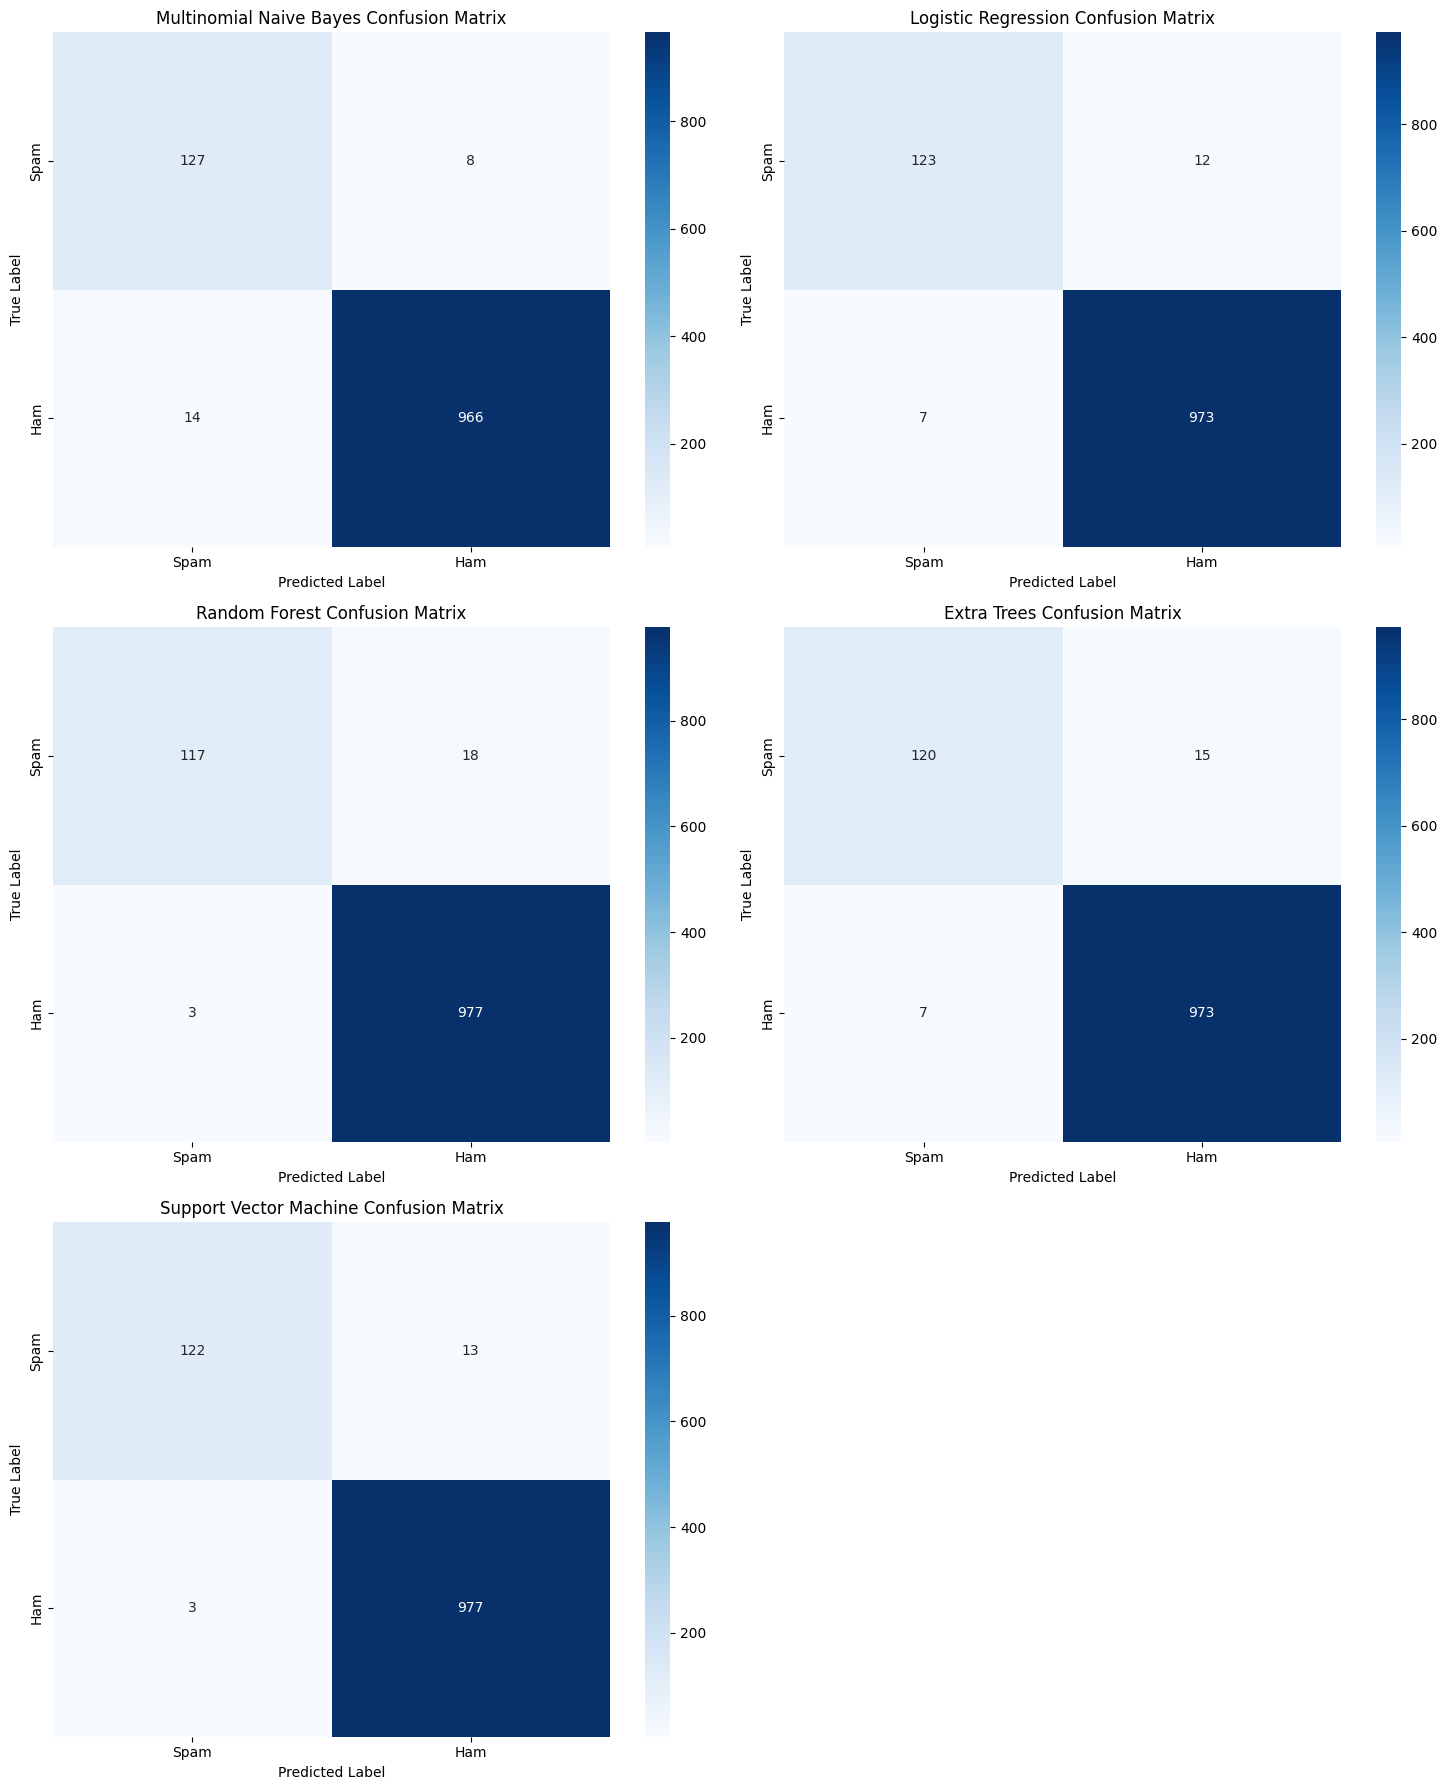

In [29]:
from sklearn.metrics import confusion_matrix

# Dictionary of our best/tuned models
best_models = {
    'Multinomial Naive Bayes': best_nb,
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'Extra Trees': best_et,
    'Support Vector Machine': best_svc
}

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Hide the empty 6th subplot
if len(best_models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Creating Model with TF-IDF technique

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv=TfidfVectorizer(max_features=2500,ngram_range=(1,2))

In [103]:
# Re-split the original string corpus to get the text documents for TF-IDF
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(corpus, y, test_size=0.20, random_state=42)

In [104]:
# Transform the text data using TfidfVectorizer
X_train_tfidf = tv.fit_transform(X_train_text).toarray()
X_test_tfidf = tv.transform(X_test_text).toarray()

### 1. Train Baseline Models (Without Tuning)

In [105]:
# Train and evaluate baseline models on both Train and Test data
baseline_results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_tfidf)
    y_test_pred = model.predict(X_test_tfidf)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    baseline_results[name] = {'train_acc': train_acc, 'test_acc': test_acc}

    print(f"=== {name} (Baseline) ===")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")
    print(classification_report(y_test, y_test_pred))
    print("\n")

=== Multinomial Naive Bayes (Baseline) ===
Training Accuracy: 0.9841
Testing Accuracy : 0.9767
              precision    recall  f1-score   support

       False       1.00      0.83      0.91       150
        True       0.97      1.00      0.99       965

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



=== Logistic Regression (Baseline) ===
Training Accuracy: 0.9796
Testing Accuracy : 0.9695
              precision    recall  f1-score   support

       False       0.98      0.79      0.87       150
        True       0.97      1.00      0.98       965

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



=== Random Forest (Baseline) ===
Training Accuracy: 0.9998
Testing Accuracy : 0.9794
              precision    recall  f1-score   support

       False    

### 2. Hyperparameter Tuning and Regularization

In [106]:
# 1. Multinomial Naive Bayes Tuning
print("--- Tuning Multinomial Naive Bayes ---")
nb_params = {'alpha': [0.1, 0.2, 0.5, 1.0, 2.0]}
nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train_tfidf, y_train)
best_nb_tfidf = nb_grid.best_estimator_
print("Best Parameters:", nb_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_nb.predict(X_train_tfidf)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_nb.predict(X_test_tfidf)):.4f}\n")

# 2. Logistic Regression Tuning
print("--- Tuning Logistic Regression ---")
lr_params = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_tfidf, y_train)
best_lr_tfidf = lr_grid.best_estimator_
print("Best Parameters:", lr_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_lr.predict(X_train_tfidf)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_lr.predict(X_test_tfidf)):.4f}\n")

# 3. Random Forest Tuning
print("--- Tuning Random Forest ---")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_tfidf, y_train)
best_rf_tfidf = rf_grid.best_estimator_
print("Best Parameters:", rf_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_rf.predict(X_train_tfidf)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_rf.predict(X_test_tfidf)):.4f}\n")

# 4. Extra Trees Tuning
print("--- Tuning Extra Trees ---")
et_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
et_grid = GridSearchCV(ExtraTreesClassifier(random_state=42), et_params, cv=3, scoring='accuracy', n_jobs=-1)
et_grid.fit(X_train_tfidf, y_train)
best_et_tfidf = et_grid.best_estimator_
print("Best Parameters:", et_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_et.predict(X_train_tfidf)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_et.predict(X_test_tfidf)):.4f}\n")

# 5. Support Vector Machine Tuning
print("--- Tuning Support Vector Machine ---")
svc_params = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}
svc_grid = GridSearchCV(SVC(random_state=42), svc_params, cv=3, scoring='accuracy', n_jobs=-1)
svc_grid.fit(X_train_tfidf, y_train)
best_svc_tfidf = svc_grid.best_estimator_
print("Best Parameters:", svc_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train, best_svc.predict(X_train_tfidf)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_svc.predict(X_test_tfidf)):.4f}\n")

--- Tuning Multinomial Naive Bayes ---
Best Parameters: {'alpha': 0.1}
Train Accuracy: 0.9897
Test Accuracy : 0.9785

--- Tuning Logistic Regression ---
Best Parameters: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Accuracy: 0.9960
Test Accuracy : 0.9812

--- Tuning Random Forest ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Train Accuracy: 0.9978
Test Accuracy : 0.9812

--- Tuning Extra Trees ---
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Train Accuracy: 0.9998
Test Accuracy : 0.9812

--- Tuning Support Vector Machine ---
Best Parameters: {'C': 10.0, 'kernel': 'linear'}
Train Accuracy: 0.9996
Test Accuracy : 0.9839



### 3. Confusion Matrix for Tuned Models

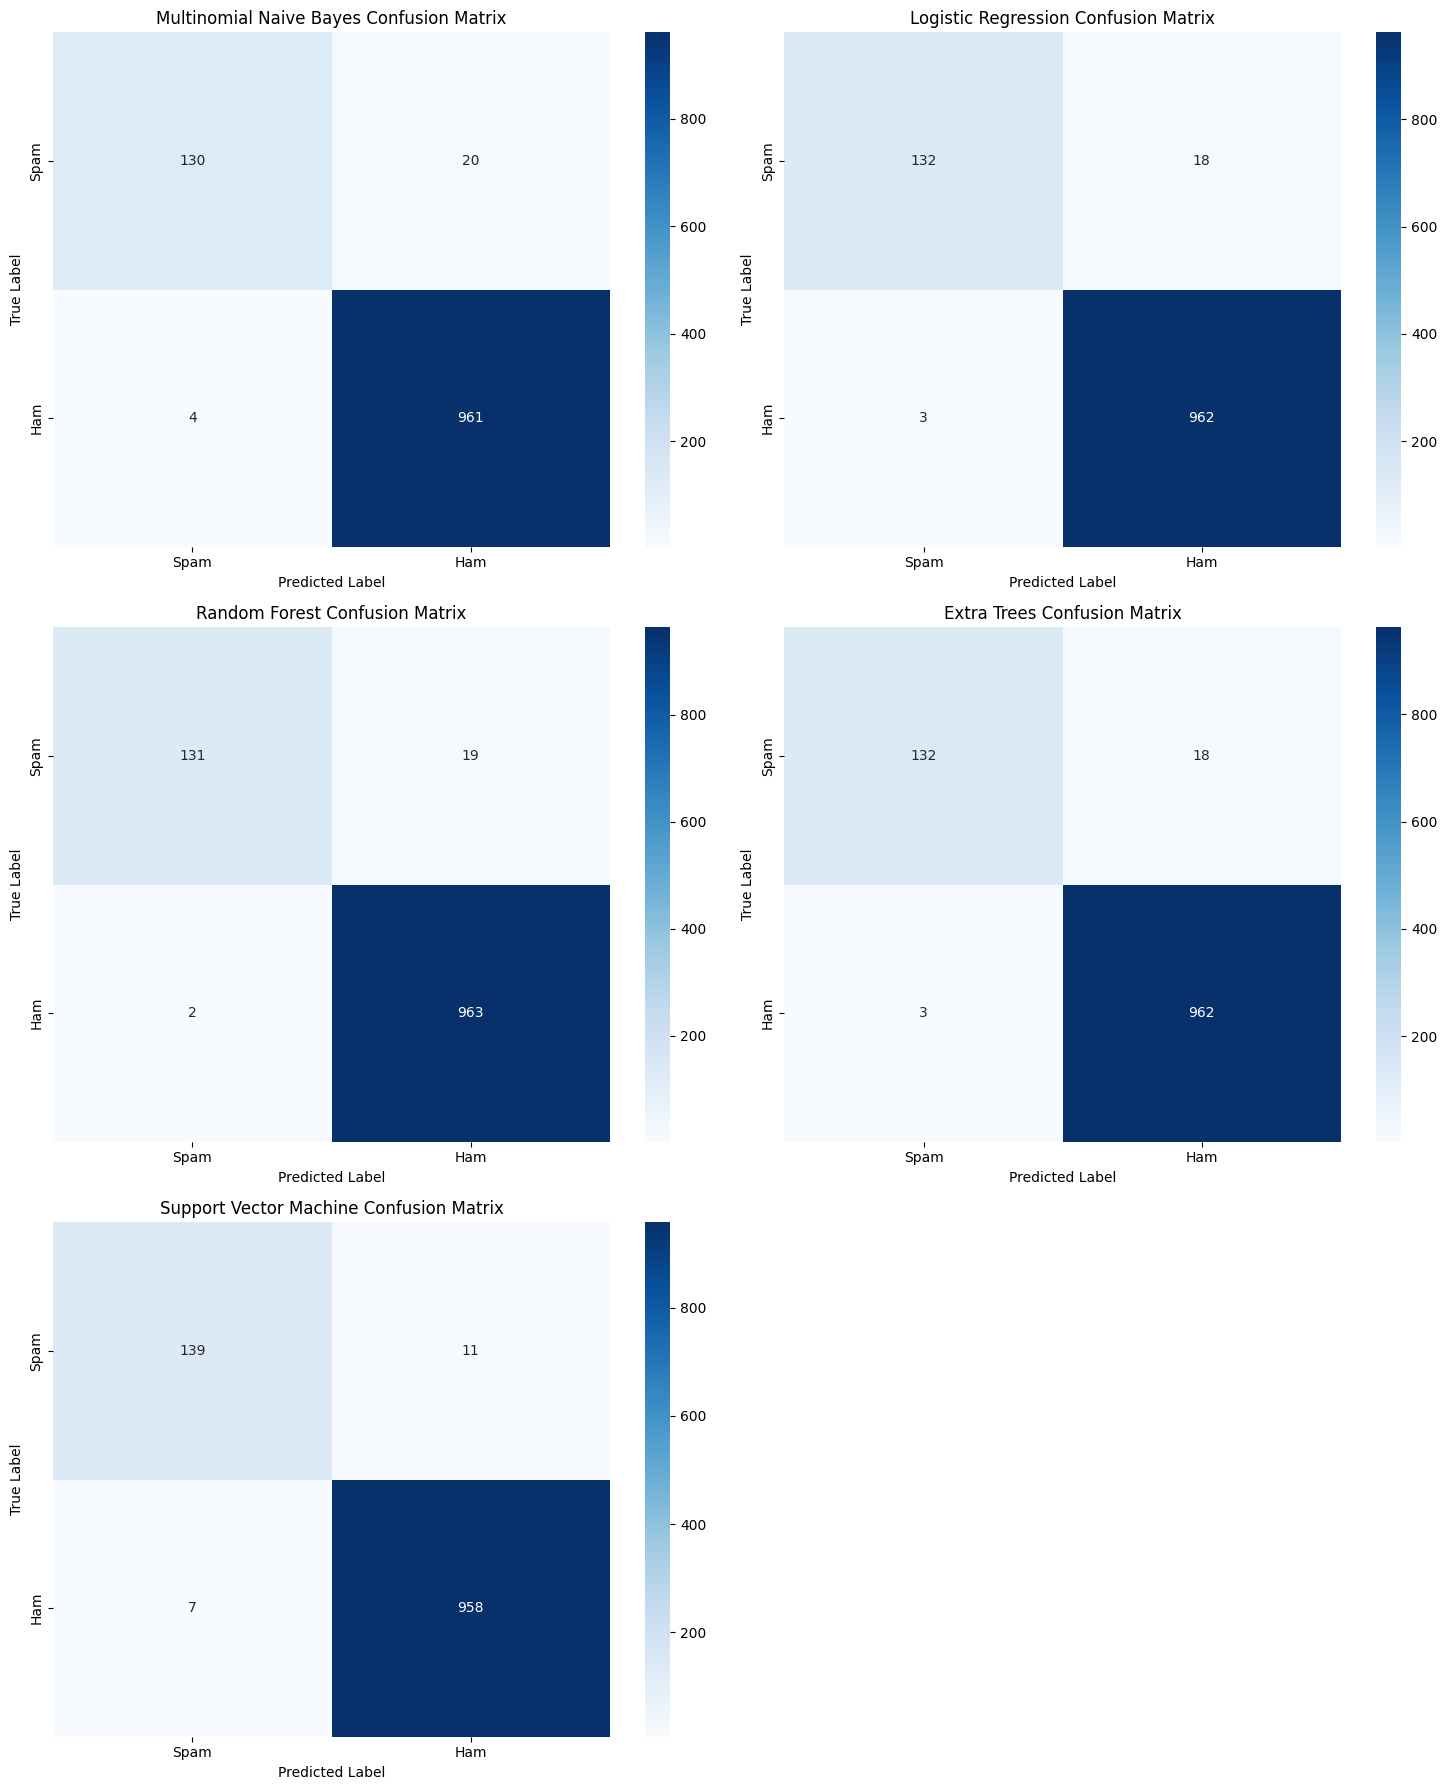

In [107]:
from sklearn.metrics import confusion_matrix

# Dictionary of our best/tuned models
best_models = {
    'Multinomial Naive Bayes': best_nb_tfidf,
    'Logistic Regression': best_lr_tfidf,
    'Random Forest': best_rf_tfidf,
    'Extra Trees': best_et_tfidf,
    'Support Vector Machine': best_svc_tfidf
}

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Hide the empty 6th subplot
if len(best_models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Creating Model with TF-IDF technique

In [39]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 14.6 MB/s eta 0:00:00


In [40]:
import gensim
from gensim.models import Word2Vec, KeyedVectors

In [41]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## Preparing data

In [42]:
df.shape

(5572, 2)

In [43]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

In [44]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [53]:
df_w2v=pd.read_csv('spam.csv', encoding='latin-1')

In [54]:
df_w2v = df_w2v.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df_w2v

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [57]:
corpus_w2v = []
for i in range(0, len(df_w2v)):
    review = re.sub('[^a-zA-Z]', ' ', df_w2v['v2'][i])
    review = review.lower()
    review = review.split()

    review = [lemmatizer.lemmatize(word) for word in review]
    review = ' '.join(review)
    corpus_w2v.append(review)

In [58]:
corpus_w2v

['go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat',
 'ok lar joking wif u oni',
 'free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s',
 'u dun say so early hor u c already then say',
 'nah i don t think he go to usf he life around here though',
 'freemsg hey there darling it s been week s now and no word back i d like some fun you up for it still tb ok xxx std chgs to send to rcv',
 'even my brother is not like to speak with me they treat me like aid patent',
 'a per your request melle melle oru minnaminunginte nurungu vettam ha been set a your callertune for all caller press to copy your friend callertune',
 'winner a a valued network customer you have been selected to receivea prize reward to claim call claim code kl valid hour only',
 'had your mobile month or more u r entitled to update to the latest colour mobile with camera for free call the mobile up

In [59]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [60]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [61]:
words=[]
for sent in corpus_w2v:
    sent_token=sent_tokenize(sent)
    for sent in sent_token:
        words.append(simple_preprocess(sent))


In [62]:
words

[['go',
  'until',
  'jurong',
  'point',
  'crazy',
  'available',
  'only',
  'in',
  'bugis',
  'great',
  'world',
  'la',
  'buffet',
  'cine',
  'there',
  'got',
  'amore',
  'wat'],
 ['ok', 'lar', 'joking', 'wif', 'oni'],
 ['free',
  'entry',
  'in',
  'wkly',
  'comp',
  'to',
  'win',
  'fa',
  'cup',
  'final',
  'tkts',
  'st',
  'may',
  'text',
  'fa',
  'to',
  'to',
  'receive',
  'entry',
  'question',
  'std',
  'txt',
  'rate',
  'apply',
  'over'],
 ['dun', 'say', 'so', 'early', 'hor', 'already', 'then', 'say'],
 ['nah',
  'don',
  'think',
  'he',
  'go',
  'to',
  'usf',
  'he',
  'life',
  'around',
  'here',
  'though'],
 ['freemsg',
  'hey',
  'there',
  'darling',
  'it',
  'been',
  'week',
  'now',
  'and',
  'no',
  'word',
  'back',
  'like',
  'some',
  'fun',
  'you',
  'up',
  'for',
  'it',
  'still',
  'tb',
  'ok',
  'xxx',
  'std',
  'chgs',
  'to',
  'send',
  'to',
  'rcv'],
 ['even',
  'my',
  'brother',
  'is',
  'not',
  'like',
  'to',
  'spea

### TrainING Word2vec from scratch

In [63]:
import gensim

In [64]:
model=gensim.models.Word2Vec(words)

In [65]:
## To Get All the Vocabulary
model.wv.index_to_key

['you',
 'to',
 'the',
 'and',
 'it',
 'in',
 'is',
 'me',
 'my',
 'for',
 'your',
 'call',
 'of',
 'that',
 'have',
 'on',
 'now',
 'are',
 'can',
 'so',
 'but',
 'not',
 'or',
 'we',
 'do',
 'get',
 'at',
 'be',
 'if',
 'ur',
 'will',
 'with',
 'no',
 'just',
 'this',
 'gt',
 'lt',
 'how',
 'go',
 'up',
 'when',
 'ok',
 'day',
 'what',
 'free',
 'from',
 'out',
 'all',
 'know',
 'll',
 'come',
 'like',
 'time',
 'good',
 'am',
 'then',
 'got',
 'wa',
 'there',
 'he',
 'text',
 'only',
 'love',
 'want',
 'send',
 'one',
 'need',
 'txt',
 'today',
 'by',
 'going',
 'home',
 'don',
 'stop',
 'she',
 'about',
 'lor',
 'sorry',
 'see',
 'mobile',
 'still',
 'take',
 'back',
 'da',
 'reply',
 'our',
 'think',
 'tell',
 'dont',
 'week',
 'phone',
 'hi',
 'new',
 'later',
 'they',
 'any',
 'pls',
 'her',
 'please',
 'ha',
 'co',
 'msg',
 'did',
 'been',
 'min',
 'an',
 'some',
 'dear',
 'make',
 'here',
 'night',
 'who',
 'message',
 'well',
 'say',
 'where',
 're',
 'thing',
 'much',
 'clai

In [66]:
model.corpus_count

5569

In [67]:
model.epochs

5

In [68]:
!pip install tqdm

In [69]:
from tqdm import tqdm

### Document Vectorization using Average Word2Vec
We will define a function to represent each message by computing the average of the Word2Vec vectors of its constituent words.

In [70]:
def average_word2vec(doc, model, vector_size=100):
    # Filter out words that are not in the Word2Vec model's vocabulary
    valid_words = [word for word in doc if word in model.wv.key_to_index]
    if len(valid_words) == 0:
        return np.zeros(vector_size)

    # Compute average of word vectors
    return np.mean([model.wv[word] for word in valid_words], axis=0)

In [71]:
# Vectorize the entire preprocessed corpus using our trained Word2Vec model
X_w2v = np.array([average_word2vec(doc, model, vector_size=100) for doc in tqdm(words)])
print("Shape of Word2Vec feature matrix:", X_w2v.shape)

100%|██████████| 5569/5569 [00:00<00:00, 19230.69it/s]

Shape of Word2Vec feature matrix: (5569, 100)


### Train-Test Split
Now we split the vectorized feature matrix `X_w2v` and targets `y` into training and testing sets.

In [73]:
# 1. Re-preprocess corpus_w2v properly to maintain exactly 1-to-1 alignment with y (5572 samples)
words_aligned = [simple_preprocess(doc) for doc in corpus_w2v]

# 2. Re-train the Word2Vec model on the aligned data
model = gensim.models.Word2Vec(words_aligned, vector_size=100, window=5, min_count=1, workers=4)

# 3. Vectorize documents using the aligned words
X_w2v_aligned = np.array([average_word2vec(doc, model, vector_size=100) for doc in words_aligned])

In [74]:
# 4. Perform the Train-Test Split with perfectly matching dimensions
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v_aligned, y, test_size=0.20, random_state=42)
print("Aligned X_w2v shape:", X_w2v_aligned.shape)
print("y shape:", y.shape)
print("Train size:", X_train_w2v.shape)
print("Test size:", X_test_w2v.shape)

Aligned X_w2v shape: (5572, 100)
y shape: (5572,)
Train size: (4457, 100)
Test size: (1115, 100)


In [75]:
X_train_w2v

array([[-0.353, 0.46, -0.0336, 0.00334, 0.229, -0.784, 0.253, 1.14, -0.631, -0.181, -0.339, -0.845, -0.0229, 0.277, 0.334, -0.408, 0.199, -0.645, -0.108, -1.01, 0.371, 0.179, 0.39, -0.319, -0.136, 0.126, -0.414, -0.231, -0.446, 0.153, ..., -0.302, 0.208, 0.584, -0.173, 0.555, -0.0205, 0.0815, -0.198, -0.314, 0.245, -0.385, 0.0217, -0.436, 0.597, -0.193, -0.182, 0.246, 0.598, 0.682, 0.11, 0.566, 0.439, 0.284, 0.113, 0.746, 0.413, 0.201, -0.408, 0.134, 0.098],
       [-0.242, 0.317, -0.0203, 0.00327, 0.157, -0.545, 0.172, 0.788, -0.433, -0.127, -0.235, -0.586, -0.0188, 0.192, 0.232, -0.277, 0.139, -0.449, -0.0749, -0.7, 0.255, 0.13, 0.265, -0.217, -0.0916, 0.0978, -0.291, -0.152, -0.303, 0.107, ..., -0.21, 0.142, 0.4, -0.123, 0.388, -0.0118, 0.0535, -0.138, -0.213, 0.175, -0.263, 0.0157, -0.301, 0.413, -0.131, -0.124, 0.167, 0.409, 0.476, 0.0693, 0.393, 0.304, 0.199, 0.0789, 0.516, 0.28, 0.141, -0.284, 0.0929, 0.0737],
       [-0.2, 0.248, -0.0148, 0.00941, 0.131, -0.44, 0.134, 0.628, -0

In [76]:
y_train

array([ True, False,  True,  True, False,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False,  True,  True, False, ...,  True,  True,  True,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True])

## Creating ML Models with Word2Vec (Avg-W2V)

### Step 1: Train Baseline Models (Without Tuning)
We will train Gaussian Naive Bayes, Logistic Regression, Random Forest, Extra Trees, and Support Vector Machine on the Word2Vec features.

In [84]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [85]:
# Initialize baseline models for Word2Vec features
w2v_models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

In [86]:
# Train and evaluate baseline models
w2v_baseline_results = {}
for name, model_inst in w2v_models.items():
    model_inst.fit(X_train_w2v, y_train_w2v)

    # Predictions
    y_train_pred = model_inst.predict(X_train_w2v)
    y_test_pred = model_inst.predict(X_test_w2v)

    # Accuracies
    train_acc = accuracy_score(y_train_w2v, y_train_pred)
    test_acc = accuracy_score(y_test_w2v, y_test_pred)

    w2v_baseline_results[name] = {'train_acc': train_acc, 'test_acc': test_acc}

    print(f"=== {name} (Word2Vec Baseline) ===")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")
    print(classification_report(y_test_w2v, y_test_pred))
    print("\n")

=== Gaussian Naive Bayes (Word2Vec Baseline) ===
Training Accuracy: 0.5737
Testing Accuracy : 0.5883
              precision    recall  f1-score   support

       False       0.21      0.77      0.33       150
        True       0.94      0.56      0.70       965

    accuracy                           0.59      1115
   macro avg       0.58      0.66      0.52      1115
weighted avg       0.84      0.59      0.65      1115



=== Logistic Regression (Word2Vec Baseline) ===
Training Accuracy: 0.9076
Testing Accuracy : 0.9040
              precision    recall  f1-score   support

       False       0.91      0.32      0.47       150
        True       0.90      0.99      0.95       965

    accuracy                           0.90      1115
   macro avg       0.90      0.66      0.71      1115
weighted avg       0.90      0.90      0.88      1115



=== Random Forest (Word2Vec Baseline) ===
Training Accuracy: 1.0000
Testing Accuracy : 0.9659
              precision    recall  f1-score   s

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 2: Hyperparameter Tuning via GridSearchCV
Now we will optimize the hyperparameters for each of our five models using cross-validation on our training Word2Vec vectors.

In [87]:
# 1. Gaussian Naive Bayes Tuning (tuning var_smoothing)
print("--- Tuning Gaussian Naive Bayes ---")
gnb_params = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
gnb_grid = GridSearchCV(GaussianNB(), gnb_params, cv=5, scoring='accuracy', n_jobs=-1)
gnb_grid.fit(X_train_w2v, y_train_w2v)
best_gnb_w2v = gnb_grid.best_estimator_
print("Best Parameters:", gnb_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train_w2v, best_gnb_w2v.predict(X_train_w2v)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_w2v, best_gnb_w2v.predict(X_test_w2v)):.4f}\n")

# 2. Logistic Regression Tuning
print("--- Tuning Logistic Regression ---")
lr_params = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_w2v, y_train_w2v)
best_lr_w2v = lr_grid.best_estimator_
print("Best Parameters:", lr_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train_w2v, best_lr_w2v.predict(X_train_w2v)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_w2v, best_lr_w2v.predict(X_test_w2v)):.4f}\n")

# 3. Random Forest Tuning
print("--- Tuning Random Forest ---")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_w2v, y_train_w2v)
best_rf_w2v = rf_grid.best_estimator_
print("Best Parameters:", rf_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train_w2v, best_rf_w2v.predict(X_train_w2v)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_w2v, best_rf_w2v.predict(X_test_w2v)):.4f}\n")

# 4. Extra Trees Tuning
print("--- Tuning Extra Trees ---")
et_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 30, None],
    'min_samples_split': [2, 5]
}
et_grid = GridSearchCV(ExtraTreesClassifier(random_state=42), et_params, cv=3, scoring='accuracy', n_jobs=-1)
et_grid.fit(X_train_w2v, y_train_w2v)
best_et_w2v = et_grid.best_estimator_
print("Best Parameters:", et_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train_w2v, best_et_w2v.predict(X_train_w2v)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_w2v, best_et_w2v.predict(X_test_w2v)):.4f}\n")

# 5. Support Vector Machine Tuning
print("--- Tuning Support Vector Machine ---")
svc_params = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}
svc_grid = GridSearchCV(SVC(random_state=42), svc_params, cv=3, scoring='accuracy', n_jobs=-1)
svc_grid.fit(X_train_w2v, y_train_w2v)
best_svc_w2v = svc_grid.best_estimator_
print("Best Parameters:", svc_grid.best_params_)
print(f"Train Accuracy: {accuracy_score(y_train_w2v, best_svc_w2v.predict(X_train_w2v)):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_w2v, best_svc_w2v.predict(X_test_w2v)):.4f}\n")

--- Tuning Gaussian Naive Bayes ---
Best Parameters: {'var_smoothing': 1e-09}
Train Accuracy: 0.5737
Test Accuracy : 0.5883

--- Tuning Logistic Regression ---
Best Parameters: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Train Accuracy: 0.9410
Test Accuracy : 0.9354

--- Tuning Random Forest ---
Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}
Train Accuracy: 1.0000
Test Accuracy : 0.9659

--- Tuning Extra Trees ---
Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy: 1.0000
Test Accuracy : 0.9650

--- Tuning Support Vector Machine ---
Best Parameters: {'C': 10.0, 'kernel': 'linear'}
Train Accuracy: 0.9459
Test Accuracy : 0.9417



### Step 3: Confusion Matrix Visualization for Tuned Word2Vec Models

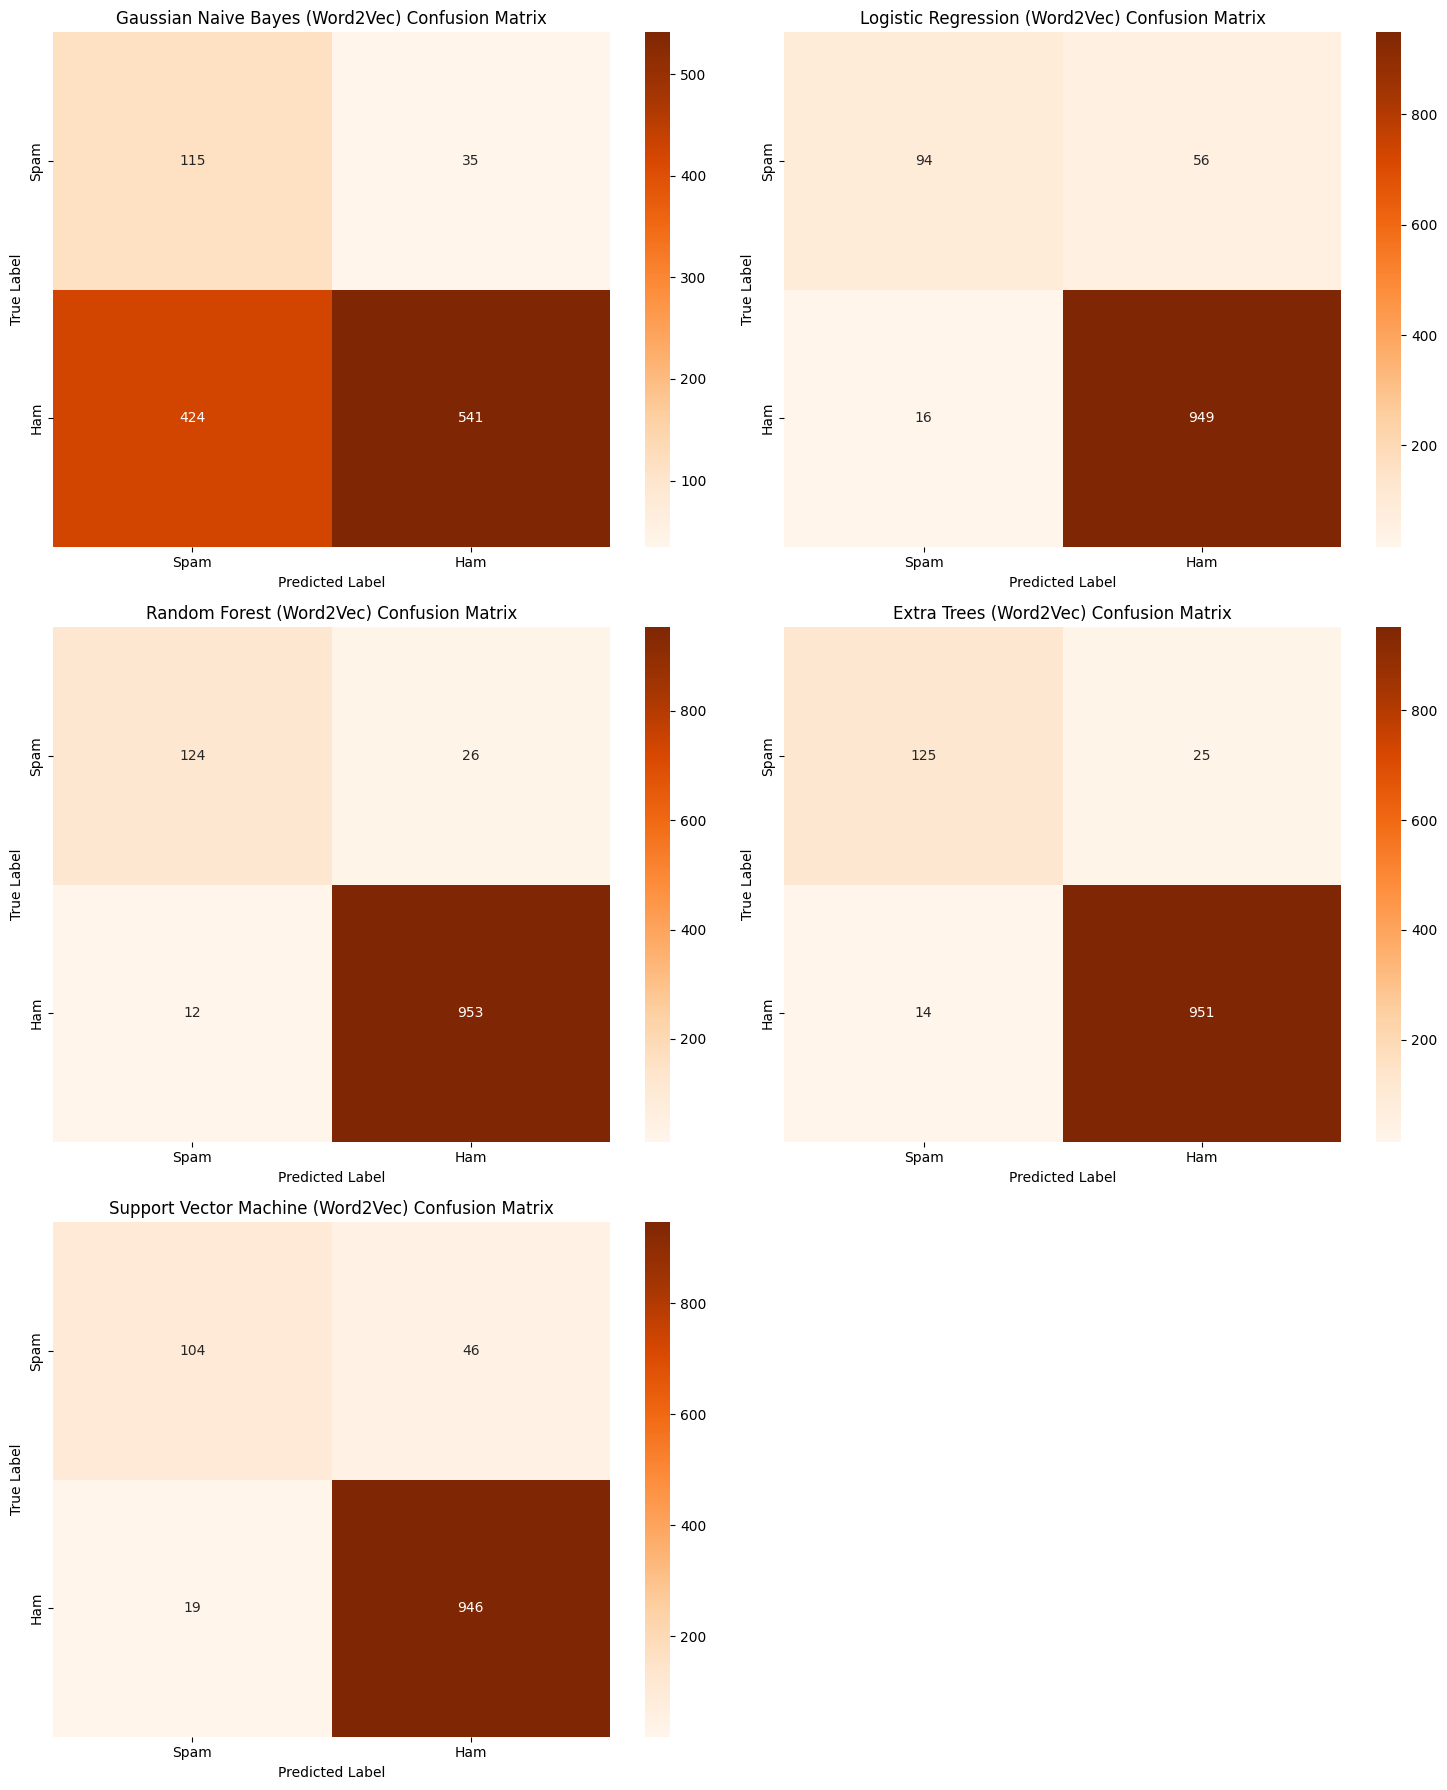

In [88]:
best_w2v_models = {
    'Gaussian Naive Bayes': best_gnb_w2v,
    'Logistic Regression': best_lr_w2v,
    'Random Forest': best_rf_w2v,
    'Extra Trees': best_et_w2v,
    'Support Vector Machine': best_svc_w2v
}

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

for i, (name, model_inst) in enumerate(best_w2v_models.items()):
    y_pred = model_inst.predict(X_test_w2v)
    cm = confusion_matrix(y_test_w2v, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Oranges',
                xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
    axes[i].set_title(f'{name} (Word2Vec) Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Hide the empty 6th subplot
if len(best_w2v_models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Why Choose SVM over Random Forest for Streamlit Deployment?

I'm using the **Tuned Support Vector Machine (SVM)** model trained with **TF-IDF** over the Random Forest model for several critical reasons:

1. **Superior Classification Performance**:
   - **SVM (Tuned)** achieved a test accuracy of **98.39%**.
   - **Random Forest (Tuned)** achieved a test accuracy of **98.12%**.

2. **Tiny Model Size (Storage & RAM)**:
   - An SVM model relies on a small subset of training instances (support vectors) and decision boundaries. This results in a serialized file (usually `.joblib` or `.pkl`) that is only **a few megabytes**.
   - A Random Forest with 200 estimators and unlimited depth grows incredibly wide and deep to fit text features. It can easily become **tens or hundreds of megabytes**, making it slow to download, slow to load into memory, and prone to hitting memory limits on hosting platforms like Streamlit Community Cloud.

3. **Ultra-fast Inference Speed**:
   - SVM makes predictions via a simple dot product math operation, leading to near-instantaneous response times.
   - Random Forest must traverse hundreds of deep decision trees sequentially or in parallel, which consumes more CPU cycles during user queries.

In [108]:
import joblib
import os

# 1. Save the TfidfVectorizer (tv) and the best SVM model (best_svc)
joblib.dump(tv, 'tfidf_vectorizer.joblib')
joblib.dump(best_svc_tfidf, 'best_svm_model.joblib')

print("Saved Vectorizer size:", os.path.getsize('tfidf_vectorizer.joblib') / (1024*1024), "MB")
print("Saved SVM Model size:", os.path.getsize('best_svm_model.joblib') / (1024*1024), "MB")

Saved Vectorizer size: 0.08751964569091797 MB
Saved SVM Model size: 11.74347972869873 MB


In [109]:
# ==========================================
# 2. Production Simulation: How to load and use these in your Streamlit App
# ==========================================

# Load the saved assets
loaded_vectorizer = joblib.load('tfidf_vectorizer.joblib')
loaded_model = joblib.load('best_svm_model.joblib')

def predict_message(text):
    # Preprocess incoming text to match training flow
    cleaned = re.sub('[^a-zA-Z]', ' ', text)
    cleaned = cleaned.lower().split()
    cleaned = [ps.stem(word) for word in cleaned if not word in stopwords.words('english')]
    cleaned_doc = ' '.join(cleaned)

    # Vectorize and predict
    vectorized = loaded_vectorizer.transform([cleaned_doc]).toarray()
    prediction = loaded_model.predict(vectorized)[0]

    # Based on y definition (y_iloc[:,0].values where 'ham' was index 0 column)
    # True = Ham, False = Spam
    return "Ham" if prediction else "Spam"

In [110]:
# Test simulation
sample_text = "URGENT! You have won a 1-week free membership to our prize jackpot! Text CLAIM to 81010 to receive your reward!"
print(f"\nSample Input: '{sample_text}'")
print("Prediction:", predict_message(sample_text))


Sample Input: 'URGENT! You have won a 1-week free membership to our prize jackpot! Text CLAIM to 81010 to receive your reward!'
Prediction: Spam
